## Titanic EDA - Summary

### Steps Performed:
1. **Loaded** the dataset (891 rows, 12 columns)
2. **Cleaned** missing values:
   - Age → filled with median
   - Embarked → filled with mode
   - Cabin → dropped (77% missing)
3. **Visualized** survival by gender, class, age, and fare
4. **Key Finding:** Gender and Class were the strongest survival factors

### Tools Used:
- `pandas` — data manipulation
- `matplotlib` / `seaborn` — visualization


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("train.csv")
print(f"Shape: {df.shape}")     
df.head()  

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#BASIC INFO 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [11]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)


C:\Users\mohamed\AppData\Local\Temp\ipykernel_44272\1959314230.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\mohamed\AppData\Local\Temp\ipykernel_44272\1959314230.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [13]:
# SUMMARY STATISTICS 
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


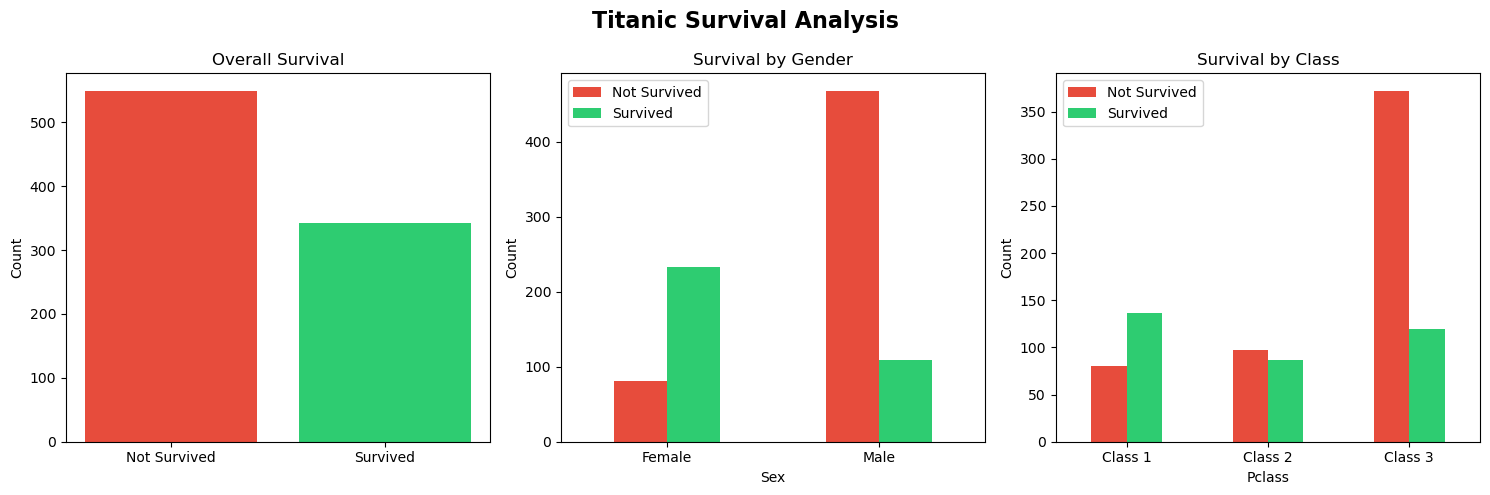

In [15]:
# ── 7. SURVIVAL ANALYSIS ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Titanic Survival Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Overall Survival ---
survival_counts = df['Survived'].value_counts()
axes[0].bar(['Not Survived', 'Survived'], survival_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='none')
axes[0].set_title('Overall Survival')
axes[0].set_ylabel('Count')


# --- Plot 2: Survival by Gender ---
gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()
gender_survival.plot(kind='bar', ax=axes[1],
                     color=['#e74c3c', '#2ecc71'], edgecolor='none')
axes[1].set_title('Survival by Gender')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['Not Survived', 'Survived'])

# --- Plot 3: Survival by Class ---
class_survival = df.groupby(['Pclass', 'Survived']).size().unstack()
class_survival.plot(kind='bar', ax=axes[2],
                    color=['#e74c3c', '#2ecc71'], edgecolor='none')
axes[2].set_title('Survival by Class')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Class 1', 'Class 2', 'Class 3'], rotation=0)
axes[2].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

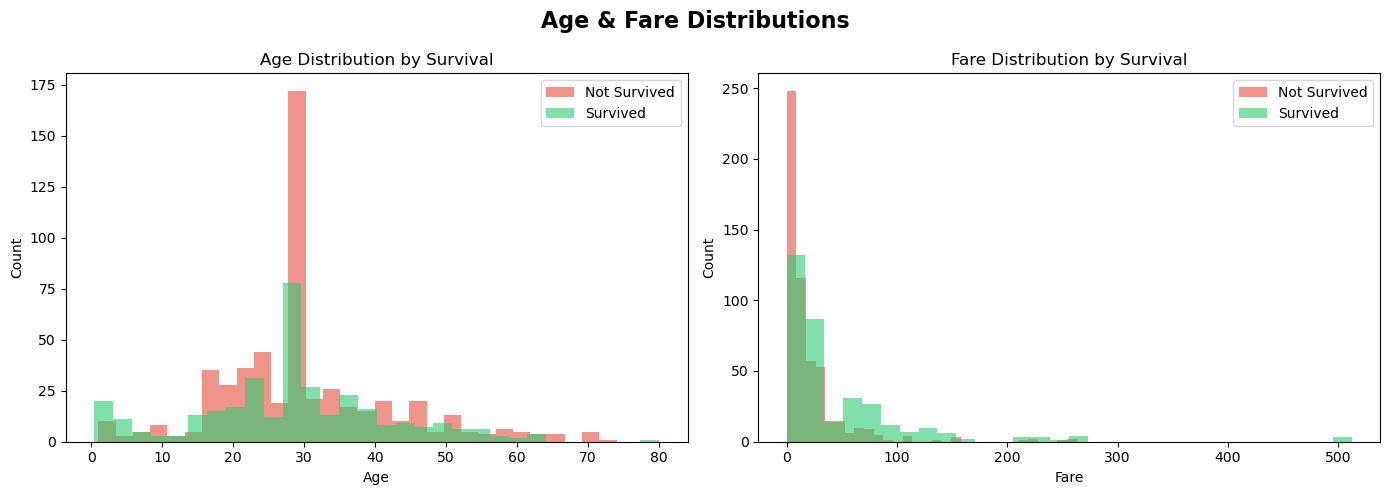

In [16]:
# ── 8. AGE & FARE DISTRIBUTIONS ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age & Fare Distributions', fontsize=16, fontweight='bold')

# --- Plot 1: Age Distribution by Survival ---
df[df['Survived'] == 0]['Age'].plot(kind='hist', bins=30, alpha=0.6,
                                    color='#e74c3c', label='Not Survived', ax=axes[0])
df[df['Survived'] == 1]['Age'].plot(kind='hist', bins=30, alpha=0.6,
                                    color='#2ecc71', label='Survived', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Fare Distribution by Survival ---
df[df['Survived'] == 0]['Fare'].plot(kind='hist', bins=30, alpha=0.6,
                                     color='#e74c3c', label='Not Survived', ax=axes[1])
df[df['Survived'] == 1]['Fare'].plot(kind='hist', bins=30, alpha=0.6,
                                     color='#2ecc71', label='Survived', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

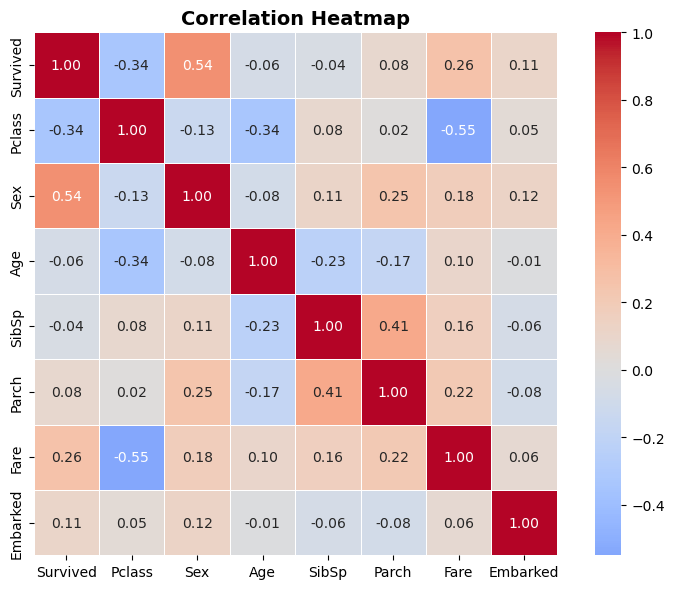

In [21]:
# ── 9. CORRELATION HEATMAP ────────────────────────────────

plt.figure(figsize=(8, 6))

# بنحول Sex و Embarked لأرقام عشان نحسب الـ correlation
df_corr = df.copy()
df_corr['Sex']      = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── 10. KEY INSIGHTS ──────────────────────────────────────

print("=" * 45)
print("        TITANIC - KEY INSIGHTS SUMMARY")
print("=" * 45)

# Overall survival rate
rate = df['Survived'].mean()
print(f"\n Overall Survival Rate: {rate:.1%}")

# By Gender
print("\n Survival by Gender:")
gender = df.groupby('Sex')['Survived'].mean()
for sex, r in gender.items():
    print(f"   {sex:8s} → {r:.1%}")

# By Class
print("\n Survival by Class:")
pclass = df.groupby('Pclass')['Survived'].mean()
for cls, r in pclass.items():
    print(f"   Class {cls}   → {r:.1%}")

# By Age group
print("\n Survival by Age Group:")
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
age = df.groupby('AgeGroup', observed=True)['Survived'].mean()
for grp, r in age.items():
    print(f"   {str(grp):12s} → {r:.1%}")

print("\n" + "=" * 45)

        TITANIC - KEY INSIGHTS SUMMARY

 Overall Survival Rate: 38.4%

 Survival by Gender:
   female   → 74.2%
   male     → 18.9%

 Survival by Class:
   Class 1   → 63.0%
   Class 2   → 47.3%
   Class 3   → 24.2%

 Survival by Age Group:
   Child        → 58.0%
   Teen         → 42.9%
   Adult        → 35.3%
   Middle-aged  → 40.0%
   Senior       → 22.7%

